In [1]:
# ============================================================
# Adult Census Income Classification
# Author: Abhishek Thakur
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

import joblib

# Plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
# ==========================================
# Load Dataset
# ==========================================

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    "../data/adult.data",
    header=None,
    names=columns,
    skipinitialspace=True
)

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
# ==========================================
# Dataset Information
# ==========================================

print("Shape of Dataset :", df.shape)
print("\n")

print("Data Types")
print(df.dtypes)

print("\n")

print("Information")
df.info()

Shape of Dataset : (32561, 15)


Data Types
age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object


Information
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str

In [4]:
# ==========================================
# Statistical Summary
# ==========================================

print("Numerical Features")
display(df.describe())

print("\nCategorical Features")
display(df.describe(include="object"))

Numerical Features


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000



Categorical Features


,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


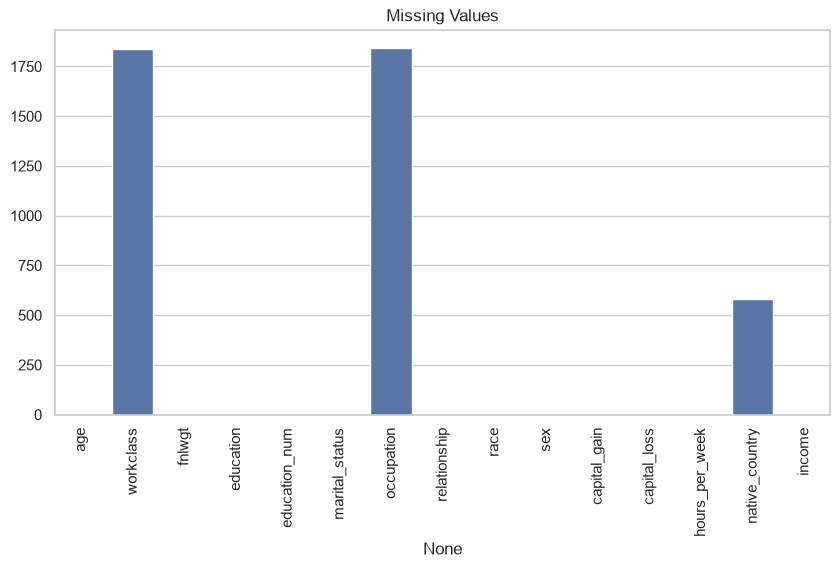

In [5]:
# ==========================================
# Missing Value Analysis
# ==========================================

df.replace("?", np.nan, inplace=True)

missing = df.isnull().sum()

print(missing)

plt.figure(figsize=(10,5))
sns.barplot(x=missing.index,y=missing.values)
plt.xticks(rotation=90)
plt.title("Missing Values")
plt.show()

In [6]:
# ==========================================
# Data Cleaning
# ==========================================

# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)

# Fill missing values with mode
for column in df.select_dtypes(include="object").columns:
    df[column].fillna(df[column].mode()[0], inplace=True)

# Check missing values
print("Missing Values After Cleaning:")
print(df.isnull().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("\nDataset Shape After Cleaning:", df.shape)

Missing Values After Cleaning:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

Dataset Shape After Cleaning: (32537, 15)


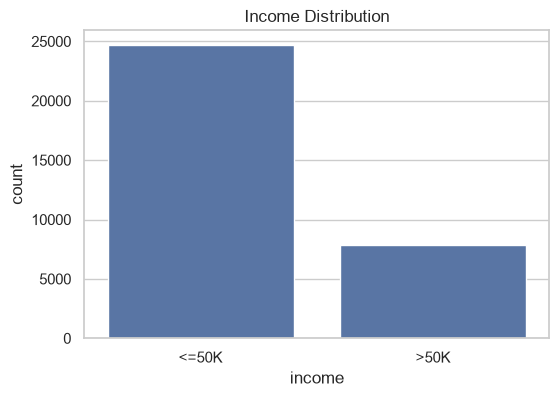

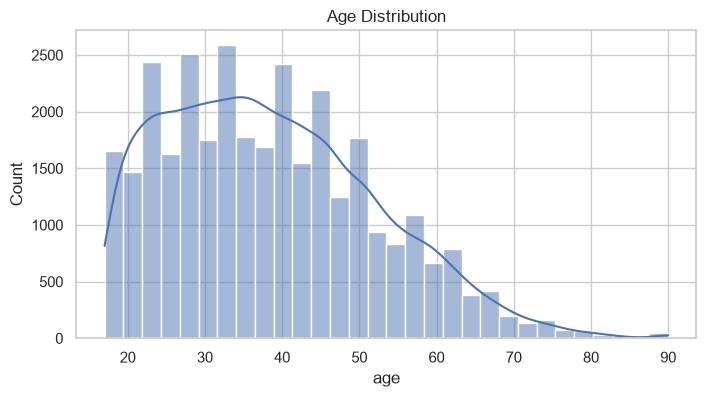

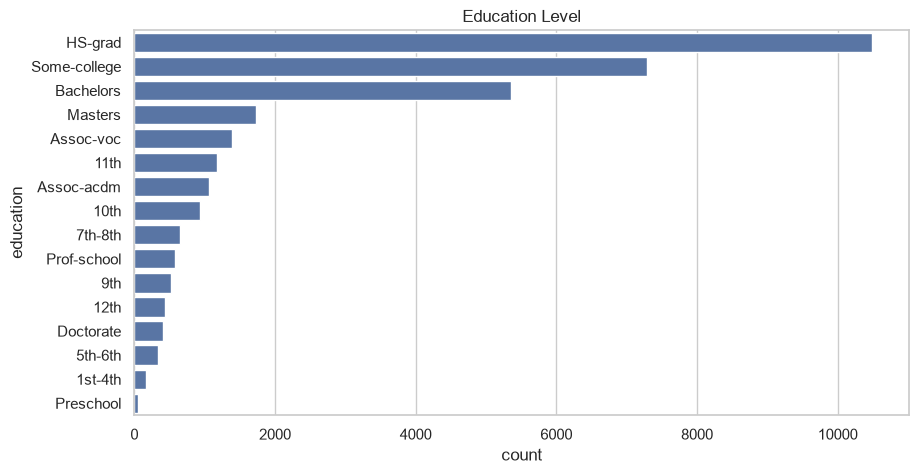

In [7]:
# ==========================================
# Exploratory Data Analysis
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x="income", data=df)
plt.title("Income Distribution")
plt.show()


plt.figure(figsize=(8,4))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


plt.figure(figsize=(10,5))
sns.countplot(y="education", data=df, order=df["education"].value_counts().index)
plt.title("Education Level")
plt.show()

In [8]:
# ==========================================
# Data Preprocessing - Label Encoding
# ==========================================

# Create a copy of the dataset
df_encoded = df.copy()

# Encode all categorical columns
label_encoder = LabelEncoder()

categorical_columns = df_encoded.select_dtypes(include="object").columns

for column in categorical_columns:
    df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

print("Categorical Features Encoded Successfully!")

df_encoded.head()

Categorical Features Encoded Successfully!


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,6,77516,9,13,4,0,1,4,1,2174,0,40,38,0
1,50,5,83311,9,13,2,3,0,4,1,0,0,13,38,0
2,38,3,215646,11,9,0,5,1,4,1,0,0,40,38,0
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,3,338409,9,13,2,9,5,2,0,0,0,40,4,0


In [9]:
# ==========================================
# Feature Scaling
# ==========================================

# Separate features and target
X = df_encoded.drop("income", axis=1)
y = df_encoded["income"]

# Scale numerical features
scaler = StandardScaler()

X = scaler.fit_transform(X)

print("Feature Scaling Completed!")

print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Feature Scaling Completed!
Shape of X : (32537, 14)
Shape of y : (32537,)


In [10]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (26029, 14)
Testing Data Shape : (6508, 14)


In [11]:
# ==========================================
# Logistic Regression
# ==========================================

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", round(lr_accuracy * 100, 2), "%")

print("\nClassification Report\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy : 82.51 %

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      4905
           1       0.72      0.48      0.57      1603

    accuracy                           0.83      6508
   macro avg       0.78      0.71      0.73      6508
weighted avg       0.81      0.83      0.81      6508



In [12]:
# ==========================================
# Decision Tree Classifier
# ==========================================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", round(dt_accuracy * 100, 2), "%")

print("\nClassification Report\n")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy : 81.04 %

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4905
           1       0.61      0.64      0.62      1603

    accuracy                           0.81      6508
   macro avg       0.74      0.75      0.75      6508
weighted avg       0.81      0.81      0.81      6508



In [13]:
# ==========================================
# Random Forest Classifier
# ==========================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", round(rf_accuracy * 100, 2), "%")

print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy : 85.88 %

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4905
           1       0.75      0.63      0.69      1603

    accuracy                           0.86      6508
   macro avg       0.82      0.78      0.80      6508
weighted avg       0.85      0.86      0.85      6508



                 Model  Accuracy (%)
2        Random Forest     85.878918
0  Logistic Regression     82.513829
1        Decision Tree     81.038722


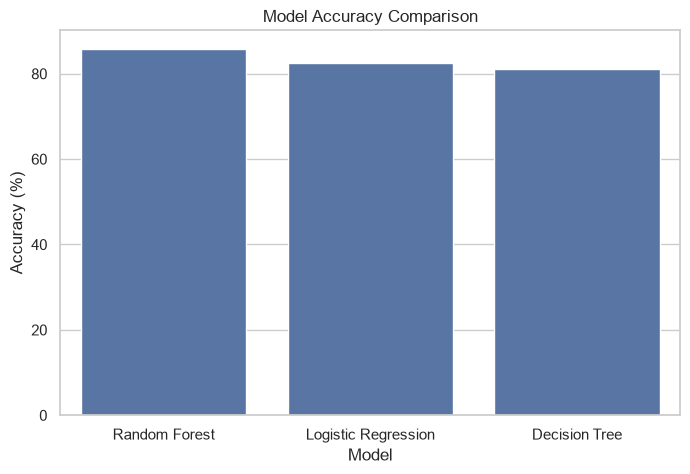

In [14]:
# ==========================================
# Model Comparison
# ==========================================

models = ["Logistic Regression", "Decision Tree", "Random Forest"]

accuracies = [
    lr_accuracy * 100,
    dt_accuracy * 100,
    rf_accuracy * 100
]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy (%)": accuracies
})

comparison = comparison.sort_values(
    by="Accuracy (%)",
    ascending=False
)

print(comparison)

plt.figure(figsize=(8,5))
sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy (%)"
)
plt.title("Model Accuracy Comparison")
plt.show()

In [15]:
# ==========================================
# Save Best Model
# ==========================================

joblib.dump(rf, "../models/random_forest_model.pkl")

joblib.dump(scaler, "../models/scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
